# Creating a Computational Political Landscape

In [1]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
import os
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, get_scheduler, AutoConfig
import datasets
from datasets import Dataset, DatasetDict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display, HTML
import plotly.io as pio
import plotly.express as px
import textwrap

In [2]:
MODEL_FOLDER = os.path.join(os.getcwd(), "weights/params_epoch_19_bs32_lr2e-05_hiddendropout0.5_attentiondropout0.5_weightdecay0.0003_warmup10")
DATA_FOLDER = os.path.join(os.getcwd(), "data")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Import BERTje model:

In [4]:
tokenizer = AutoTokenizer.from_pretrained("GroNLP/bert-base-dutch-cased")
model = AutoModel.from_pretrained(MODEL_FOLDER,
    output_hidden_states=True)
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30073, 768, padding_idx=3)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.5, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.5, inplace=False

## Import data and prepare data:

In [5]:
df = pd.read_csv(os.path.join(DATA_FOLDER, 'test.csv'))
schoof = pd.read_csv(os.path.join(DATA_FOLDER, 'schoof.csv'))
train = pd.read_csv(os.path.join(DATA_FOLDER, 'train.csv'))
df.reset_index()
schoof.reset_index()
train.reset_index()
ds = Dataset.from_pandas(df)
schoof_ds = Dataset.from_pandas(schoof)
train_ds = Dataset.from_pandas(train)
data = DatasetDict()
data['test'] = ds
data['schoof'] = schoof_ds
data['train'] = train_ds

In [6]:
def tokenize_speech(speech):
    return tokenizer(speech['Text'], padding='max_length', truncation=True, max_length=512, return_tensors='pt')

In [7]:
batch_size = 32

tokenized_data = data.map(tokenize_speech, batched=True)
tokenized_data = tokenized_data.remove_columns(["Text"])
tokenized_data = tokenized_data.rename_column("Label", "labels")
labels_list = df['Label']
speaker_list = df['Speaker']
tokenized_data = tokenized_data.remove_columns(["Speaker"])
tokenized_data = tokenized_data.remove_columns(["Party"])
tokenized_data = tokenized_data.remove_columns(["labels"])
tokenized_data.set_format("torch")
test_dataset = tokenized_data['test']
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
schoof_dataset = tokenized_data['schoof']
schoof_dataloader = DataLoader(schoof_dataset, batch_size=32, shuffle=False)
train_dataset = tokenized_data['train']
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)

Map:   0%|          | 0/4191 [00:00<?, ? examples/s]

Map:   0%|          | 0/973 [00:00<?, ? examples/s]

Map:   0%|          | 0/33527 [00:00<?, ? examples/s]

## Embed everything using the fine-tuned BERT:

In [8]:
total_speeches = test_dataset.num_rows+schoof_dataset.num_rows

embeddings = torch.zeros((total_speeches,768))

# Embed test set
for i, batch in tqdm(enumerate(test_dataloader)):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        embedding_batch = model(**batch).pooler_output  # shape (32,568)
    start = i * batch_size
    end = min(start + batch_size, len(df))
    embeddings[start:end, :] = embedding_batch

# Embed schoof set
for i, batch in tqdm(enumerate(schoof_dataloader)):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        embedding_batch = model(**batch).pooler_output  # shape (32,568)
    start = i * batch_size
    end = min(start + batch_size, len(df))
    embeddings[test_dataset.num_rows+start:test_dataset.num_rows+end, :] = embedding_batch

train_total_speeches = train_dataset.num_rows
train_embeddings = torch.zeros((train_total_speeches,768))

# Embed train set
for i, batch in tqdm(enumerate(train_dataloader)):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        embedding_batch = model(**batch).pooler_output  # shape (32,568)
    start = i * batch_size
    end = min(start + batch_size, len(train))
    train_embeddings[start:end, :] = embedding_batch

131it [00:54,  2.39it/s]
31it [00:13,  2.33it/s]
1048it [07:53,  2.21it/s]


## Use Factor Analysis to plot in 2D:

In [9]:
from sklearn.decomposition import FactorAnalysis
fa = FactorAnalysis(n_components=2)
# Fit on train set:
train_fitted = fa.fit_transform(train_embeddings)
# Transform test set:
data_fitted = fa.transform(embeddings)

In [10]:
all_labels = pd.concat([df['Label'], schoof['Label']])
all_labels = all_labels.reset_index()
all_labels = all_labels.drop('index', axis=1)

all_speakers = pd.concat([df['Speaker'], schoof['Speaker']])
all_speakers = all_speakers.reset_index()
all_speakers = all_speakers.drop('index', axis=1)

train_labels = train['Label']
train_labels = train_labels.reset_index()
train_labels = train_labels.drop('index', axis=1)

train_speakers = train['Speaker']
train_speakers = train_speakers.reset_index()
train_speakers = train_speakers.drop('index', axis=1)


### Plot test set per sample:

(5164, 2)


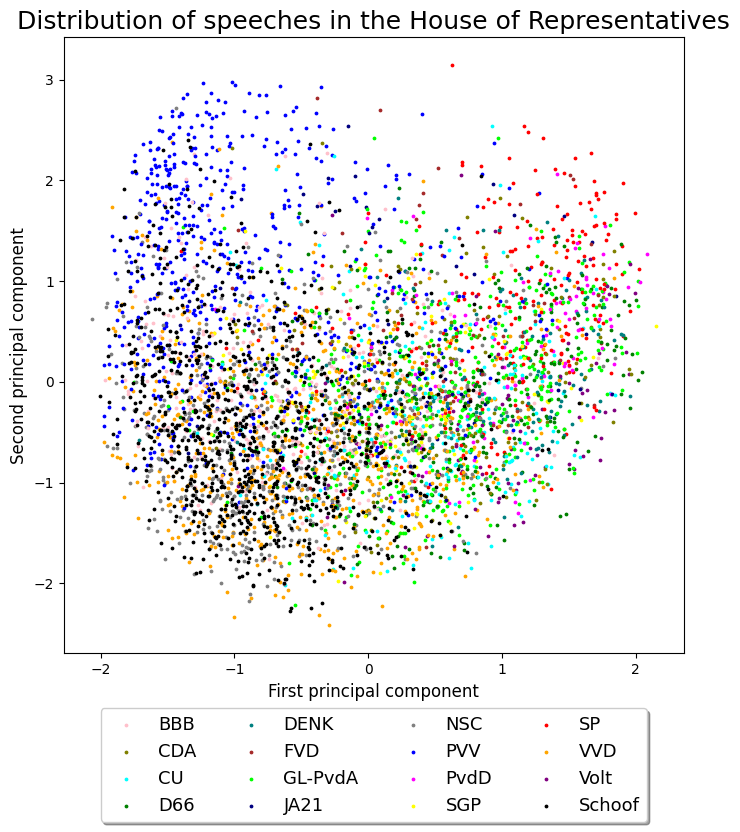

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

colours = {0: 'pink', 1: 'olive', 2: 'cyan', 3: 'green',
           4: 'teal', 5: 'brown', 6: 'lime', 7: 'navy',
           8: 'gray', 9:'blue', 10: 'magenta', 11: 'yellow',
           12: 'red', 13: 'orange', 14: 'purple', 15: 'black'}
labels = {0: 'BBB', 1: 'CDA', 2: 'CU', 3: 'D66',
          4: 'DENK', 5: 'FVD', 6: 'GL-PvdA', 7: 'JA21',
          8: 'NSC', 9: 'PVV', 10: 'PvdD', 11: 'SGP',
          12: 'SP', 13: 'VVD', 14: 'Volt', 15: 'Schoof'}

print(data_fitted.shape)
label_idx = 0
for i in range(len(data_fitted)):
    label = all_labels['Label'][i]

    # Influence sequence in which labels are added to the legend:
    if label == label_idx:
        use_label = labels[label]
        label_idx += 1
    else:
        use_label = "_nolabel_"
    ax.scatter(data_fitted[i][0], data_fitted[i][1], color=colours[label], s=3, label=use_label)

ax.set_xlabel("First principal component", fontsize=12)
ax.set_ylabel("Second principal component", fontsize=12)
ax.set_title("Distribution of speeches in the House of Representatives", fontsize=18)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075), fancybox=True, shadow=True, ncol=4, fontsize=13)
plt.savefig("plots/separate_speeches_test_set.png")
plt.show()

## Compute average embeddings:

In [12]:
# Group by party for test set:
party_speeches = [list() for _ in range(16)]

for i in range(len(data_fitted)):
    label = all_labels['Label'][i]
    party_speeches[label].append(data_fitted[i,:])

# Group by party for training set:
train_speeches = [list() for _ in range(16)]

for i in range(len(train_fitted)):
    label = train_labels['Label'][i]
    train_speeches[label].append(train_fitted[i,:])

In [13]:
# Compute test set averages:
avgs = np.zeros((2,16))
stds = np.zeros((2,16))

for i,party_speech in enumerate(party_speeches):
    party_speech = np.array(party_speech)
    avg_speech = np.mean(party_speech, axis=0)
    std_speech = np.std(party_speech, axis=0)
    avgs[:,i] = avg_speech
    stds[:,i] = std_speech

# Compute training set averages:
train_avgs = np.zeros((2,16))
train_stds = np.zeros((2,16))

for i,train_speech in enumerate(train_speeches):
    train_speech = np.array(train_speech)
    avg_speech = np.mean(train_speech, axis=0)
    std_speech = np.std(train_speech, axis=0)
    train_avgs[:,i] = avg_speech
    train_stds[:,i] = std_speech

/vol/tensusers8/wledder/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/vol/tensusers8/wledder/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/vol/tensusers8/wledder/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/vol/tensusers8/wledder/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/vol/tensusers8/wledder/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


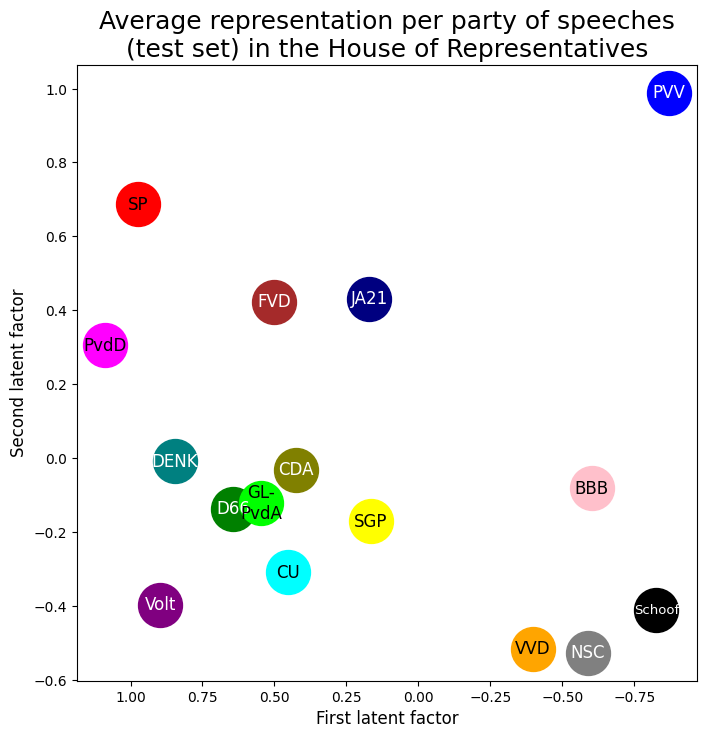

In [14]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

colours = {0: 'pink', 1: 'olive', 2: 'cyan', 3: 'green',
           4: 'teal', 5: 'brown', 6: 'lime', 7: 'navy',
           8: 'gray', 9:'blue', 10: 'magenta', 11: 'yellow',
           12: 'red', 13: 'orange', 14: 'purple', 15: 'black'}
labels = {0: 'BBB', 1: 'CDA', 2: 'CU', 3: 'D66',
          4: 'DENK', 5: 'FVD', 6: 'GL-\nPvdA', 7: 'JA21',
          8: 'NSC', 9: 'PVV', 10: 'PvdD', 11: 'SGP',
          12: 'SP', 13: 'VVD', 14: 'Volt', 15: 'Schoof'}

white_letter_indices = [1, 3, 4, 5, 7, 8, 9, 14, 15]
for i in range(len(avgs[0])):
    ax.text(avgs[0][i], avgs[1][i], labels[i], fontsize=12 if i!= 15 else 9.5, c='w' if i in white_letter_indices else 'k', ha='center', va='center')
    ax.scatter(avgs[0][i], avgs[1][i], color=colours[i], s=1000) # label=labels[i])
ax.set_xlabel("First latent factor", fontsize=12)
ax.set_ylabel("Second latent factor", fontsize=12)
ax.set_title("Average representation per party of speeches\n(test set) in the House of Representatives", fontsize=18)
ax.invert_xaxis()

plt.savefig("plots/computational_political_landscape_test_set.png")
plt.show()

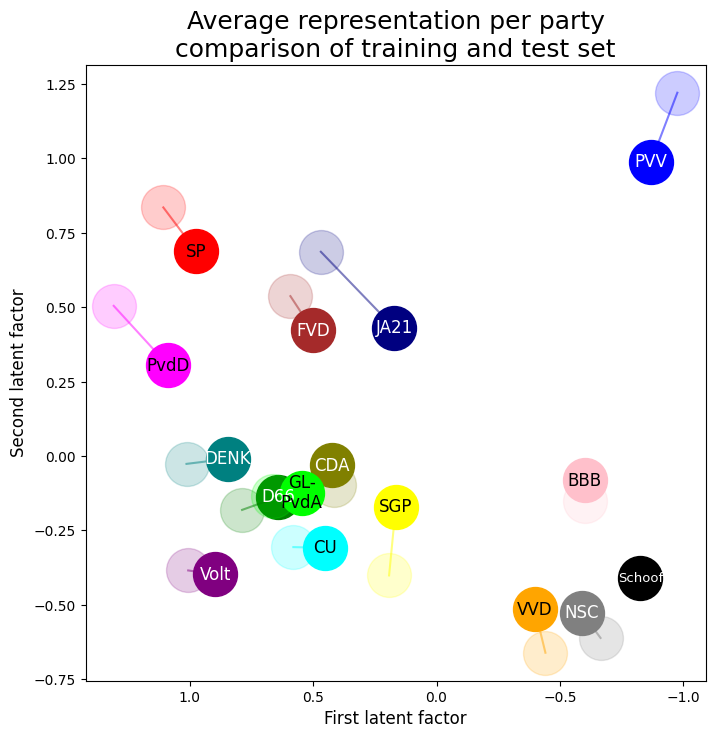

In [15]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

colours = {0: 'pink', 1: 'olive', 2: 'cyan', 3: 'green',
           4: 'teal', 5: 'brown', 6: 'lime', 7: 'navy',
           8: 'gray', 9:'blue', 10: 'magenta', 11: 'yellow',
           12: 'red', 13: 'orange', 14: 'purple', 15: 'black'}
labels = {0: 'BBB', 1: 'CDA', 2: 'CU', 3: 'D66',
          4: 'DENK', 5: 'FVD', 6: 'GL-\nPvdA', 7: 'JA21',
          8: 'NSC', 9: 'PVV', 10: 'PvdD', 11: 'SGP',
          12: 'SP', 13: 'VVD', 14: 'Volt', 15: 'Schoof'}

white_letter_indices = [1, 3, 4, 5, 7, 8, 9, 14, 15]
for i in range(len(avgs[0])):
    ax.scatter(train_avgs[0][i], train_avgs[1][i], color=colours[i], s=1000, alpha=0.2) # label=labels[i])
    ax.text(avgs[0][i], avgs[1][i], labels[i], fontsize=12 if i!= 15 else 9.5, c='w' if i in white_letter_indices else 'k', ha='center', va='center')
    ax.scatter(avgs[0][i], avgs[1][i], color=colours[i], s=1000) # label=labels[i])
    ax.plot([avgs[0][i], train_avgs[0][i]], [avgs[1][i], train_avgs[1][i]], color=colours[i], alpha=0.5)
ax.set_xlabel("First latent factor", fontsize=12)
ax.set_ylabel("Second latent factor", fontsize=12)
ax.set_title("Average representation per party\ncomparison of training and test set", fontsize=18)
ax.invert_xaxis()
plt.savefig("plots/computational_political_landscape_train_test_set.png")
plt.show()

## Make distance matrix:

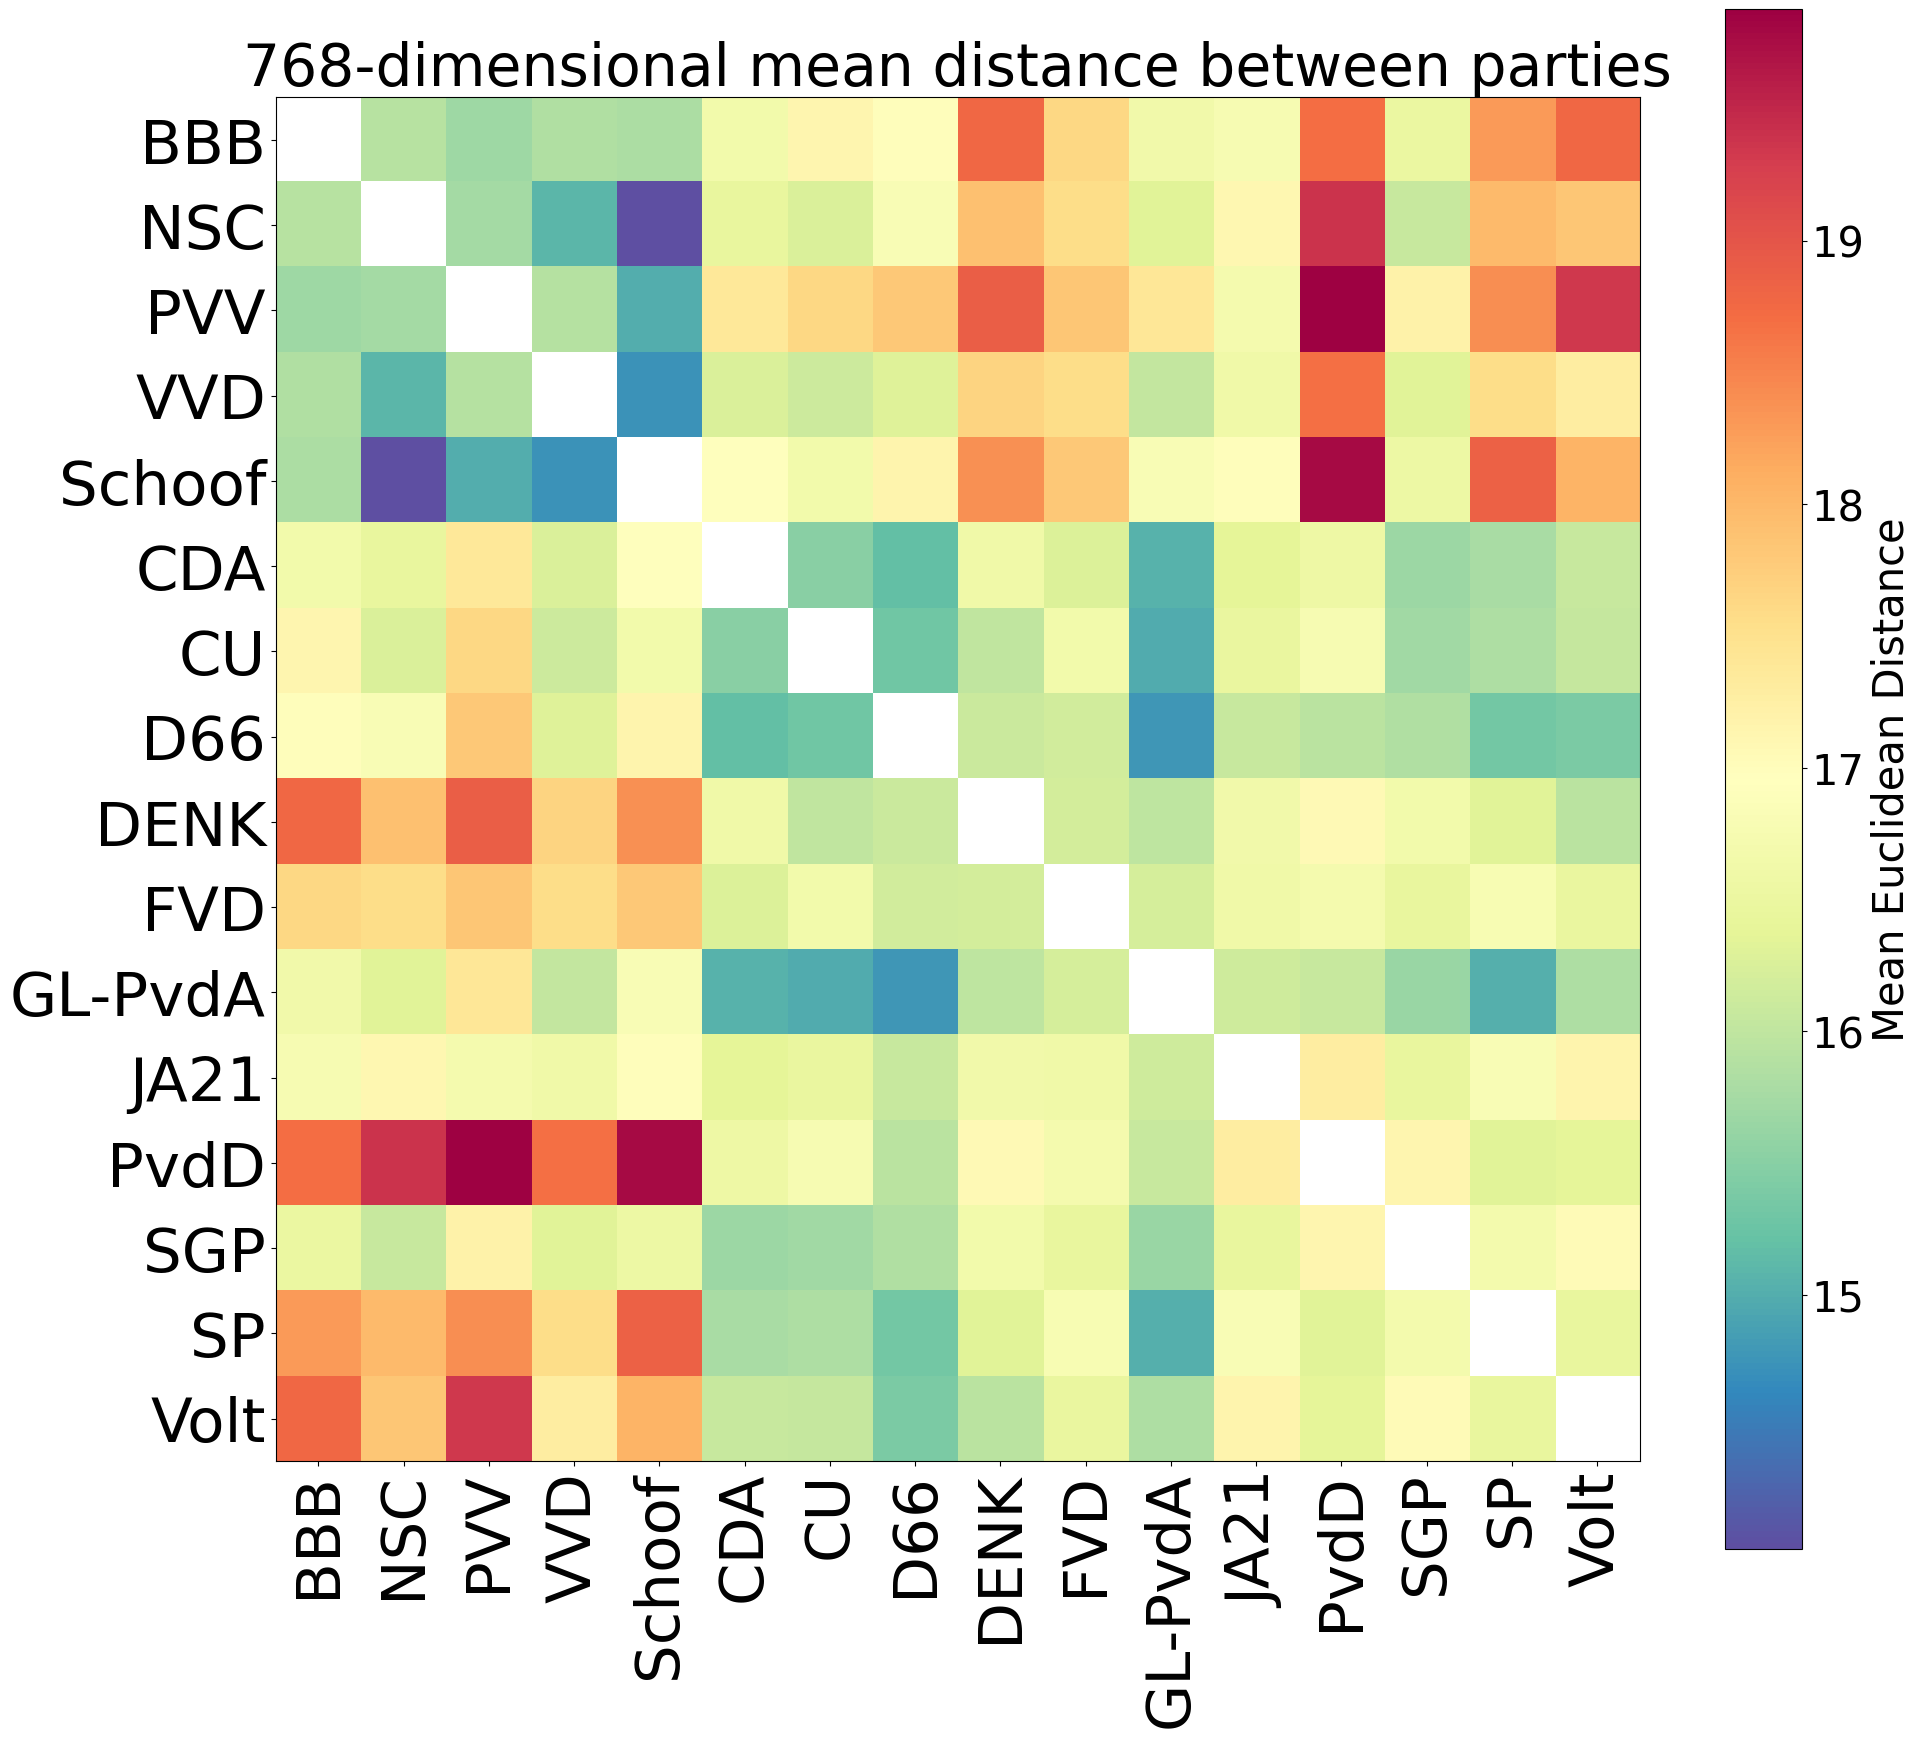

In [16]:
from scipy.spatial.distance import cdist

def mean_distance_matrix(groups):
    n = len(groups)
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            if len(groups[i]) == 0 or len(groups[j]) == 0:
                mean_dist = np.nan
            else:
                dists = cdist(np.vstack(groups[i]), np.vstack(groups[j]), metric="euclidean")
                mean_dist = dists.mean()
            if i == j:  # force diagonal to 0
                mean_dist = 0.0
            dist_matrix[i, j] = mean_dist
            dist_matrix[j, i] = mean_dist
    return dist_matrix


all_speeches = [list() for _ in range(16)]

labels = {0: 'BBB', 1: 'CDA', 2: 'CU', 3: 'D66',
          4: 'DENK', 5: 'FVD', 6: 'GL-PvdA', 7: 'JA21',
          8: 'NSC', 9: 'PVV', 10: 'PvdD', 11: 'SGP',
          12: 'SP', 13: 'VVD', 14: 'Volt', 15: 'Schoof'}

for i in range(embeddings.shape[0]):
    label = all_labels['Label'][i]
    all_speeches[label].append(embeddings[i])

dist_matrix = mean_distance_matrix(all_speeches)

rows_to_front = [0, 8, 9, 13, 15]

new_order = rows_to_front + [i for i in range(dist_matrix.shape[0]) if i not in rows_to_front]
dist_matrix = dist_matrix[np.ix_(new_order, new_order)]

masked = np.ma.masked_where(np.eye(dist_matrix.shape[0], dtype=bool), dist_matrix)

plt.figure(figsize=(22,20))
im = plt.imshow(masked, cmap="Spectral_r") # gist_heat_r
cbar = plt.colorbar(im)
cbar.set_label("Mean Euclidean Distance", fontsize=30)
cbar.ax.tick_params(labelsize=30)  # Set colorbar ticks font size
plt.title("768-dimensional mean distance between parties", fontsize=42)
plt.xticks(range(16), [labels[i] for i in new_order], rotation=90, ha="center", fontsize=44)
plt.yticks(range(16), [labels[i] for i in new_order], fontsize=44)
plt.savefig("plots/distance_matrix.png")
plt.show()

## Make interactive plot:

In [17]:
def wrap_text(s, width=80):
    return "<br>".join(textwrap.wrap(s, width=width))

df_speeches_and_latents = pd.DataFrame({
    "First latent factor": data_fitted[:,0],
    "Second latent factor": data_fitted[:,1],
    "text": df["Text"].tolist() + schoof["Text"].tolist(),
    "speaker": df["Speaker"].tolist() + schoof["Speaker"].tolist(),
    "party": df["Party"].tolist() + schoof["Party"].tolist()
})

df_plotting = df_speeches_and_latents.copy()

df_plotting["text"] = df_speeches_and_latents["text"].apply(lambda x: wrap_text(x, 80))


In [18]:
fig = px.scatter(
    df_plotting,
    x="First latent factor",
    y="Second latent factor",
    hover_data={"speaker": True, "text": True},
    color="party",
    color_discrete_map={'BBB': 'pink', 'CDA': 'olive', 'ChristenUnie': 'cyan', 'D66': 'green',
           'DENK': 'teal', 'FVD': 'brown', 'GroenLinks-PvdA': 'lime', 'JA21': 'navy',
           'NSC': 'gray', 'PVV':'blue', 'PvdD': 'magenta', 'SGP': 'yellow',
           'SP': 'red', 'VVD': 'orange', 'Volt': 'purple', 'Schoof': 'black'}
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    title="PCA of Text Embeddings",
    xaxis_title="First latent factor",
    yaxis_title="Second latent factor",
    width=1000,
    height=1000,
    xaxis=dict(autorange="reversed")
)

html_str = pio.to_html(fig, include_plotlyjs="cdn", full_html=False)
display(HTML(html_str))

## Compute LIWC scores:

In [19]:
df_plotting.sort_values('Second latent factor', ascending=True).head(200)['text'].to_csv("liwc_data/lowest_second_factor.csv", index=False, encoding="utf-8-sig")
df_plotting.sort_values('Second latent factor', ascending=False).head(200)['text'].to_csv("liwc_data/highest_second_factor.csv", index=False, encoding="utf-8-sig")

Now, text should be translated (we used Google Translate) and fed into LIWC-22.

This is paid software, hence, we open the translated and processed values below:

In [20]:
df_liwc_lowest = pd.read_csv('liwc_data/lowest_second_factor_liwc.csv')
df_liwc_highest = pd.read_csv('liwc_data/highest_second_factor_liwc.csv')

In [21]:
for variable in df_liwc_highest.columns:
    if variable in ['text', 'party', 'speaker']:
        continue
    print(variable, [float(np.mean(df_liwc_lowest[variable])), float(np.mean(df_liwc_highest[variable]))])

Segment [1.0, 1.0]
WC [234.1, 187.585]
Analytic [59.75665, 43.951100000000004]
Clout [39.213499999999996, 41.8183]
Authentic [55.1801, 49.59495]
Tone [51.01609375, 40.973499999999994]
WPS [19.948449999999998, 14.679749999999999]
BigWords [24.5324, 22.034350000000003]
Dic [89.3933, 89.0549]
Linguistic [69.67595, 71.26280000000001]
function [58.18035, 60.205149999999996]
pronoun [14.175, 14.79105]
ppron [6.7125, 7.050949999999999]
i [3.5375, 3.0060000000000002]
we [1.9015, 1.72765]
you [0.54325, 1.1795]
shehe [0.26835, 0.22910000000000003]
they [0.36840000000000006, 0.6762]
ipron [7.4622, 7.740049999999999]
det [17.19825, 16.49785]
article [8.675899999999999, 8.25635]
number [0.9946, 1.4360500000000003]
prep [14.666550000000003, 12.855300000000002]
auxverb [8.2053, 10.694700000000001]
adverb [6.2452499999999995, 6.6030999999999995]
conj [6.135999999999999, 6.312700000000001]
negate [1.1096500000000002, 2.02095]
verb [14.16465, 17.1689]
adj [5.630599999999999, 4.7623500000000005]
quantity

### Most notable, Analytical thinking has a large gap:

Lowest second latent values, LIWC average score: 59.75665
Highest second latent values, LIWC average score: 43.951100000000004


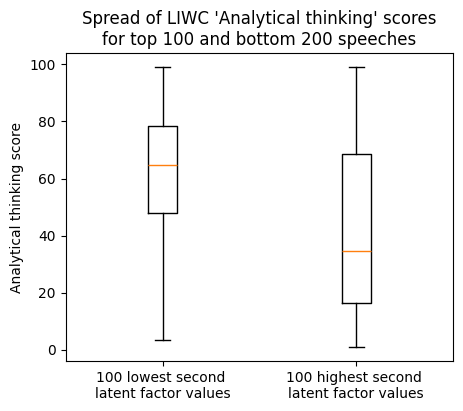

In [22]:
print("Lowest second latent values, LIWC average score:", df_liwc_lowest['Analytic'].mean())
print("Highest second latent values, LIWC average score:", df_liwc_highest['Analytic'].mean())

plt.figure(figsize=(5,4))
plt.boxplot([df_liwc_lowest['Analytic'].head(100), df_liwc_highest['Analytic'].tail(100)])
plt.xticks([1,2], ['100 lowest second \nlatent factor values', '100 highest second \nlatent factor values'])
plt.title("Spread of LIWC 'Analytical thinking' scores\nfor top 100 and bottom 200 speeches")
plt.ylabel("Analytical thinking score")
plt.savefig("plots/boxplot_liwc.png")
plt.show()

## BERT performance:

This has not been discussed in the paper, but it shows why the BERT model with a train accuracy of 59\% and a test accuracy of 42\% is still adequate for our purpose.

We do not fine-tune BERT for making it guess the political party - we fine-tune it to have it learn ideological stances.

Hence, we show the following cofusion matrix:

In [23]:
# Load the model with the output classification layer:
tokenizer = AutoTokenizer.from_pretrained("GroNLP/bert-base-dutch-cased")
config = AutoConfig.from_pretrained(MODEL_FOLDER)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_FOLDER, config=config).to(device)

In [24]:
# Load the data similarly to the fine-tuning script:
df_schoof = pd.read_csv(os.path.join(DATA_FOLDER, 'schoof.csv'))
df_test = pd.read_csv(os.path.join(DATA_FOLDER, 'test.csv'))
ds_schoof = Dataset.from_pandas(df_schoof)
ds_test = Dataset.from_pandas(df_test)
data = DatasetDict()
data['schoof'] = ds_schoof
data['test'] = ds_test

def tokenize_speech(speech):
    return tokenizer(speech['Text'], padding='max_length', truncation=True,
                     max_length=512, return_tensors='pt')

tokenized_data = data.map(tokenize_speech, batched=True)
tokenized_data = tokenized_data.remove_columns(["Text"])
tokenized_data = tokenized_data.remove_columns(["Speaker"])
tokenized_data = tokenized_data.remove_columns(["Party"])
tokenized_data = tokenized_data.rename_column("Label", "labels")
tokenized_data.set_format("torch")
schoof_dataset = tokenized_data["schoof"]
test_dataset = tokenized_data["test"]
schoof_dataloader = DataLoader(schoof_dataset, shuffle=True, batch_size=8)
test_dataloader = DataLoader(test_dataset, batch_size=8)

Map:   0%|          | 0/973 [00:00<?, ? examples/s]

Map:   0%|          | 0/4191 [00:00<?, ? examples/s]

In [25]:
model.eval()

all_predictions = []
all_labels = []

for batch in schoof_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    batch["labels"] = torch.zeros_like(batch["labels"])
    outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    all_predictions.append(predictions.flatten().tolist())
    all_labels.append(dict(batch.items())['labels'].tolist())

all_labels = [[x + 15 for x in sublist] for sublist in all_labels]

for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    all_predictions.append(predictions.flatten().tolist())
    all_labels.append(dict(batch.items())['labels'].tolist())


In [26]:
def plot_confusion_matrix(all_labels, all_predictions):
    all_labels = flatmap_lists(all_labels)
    all_predictions = flatmap_lists(all_predictions)

    # Sort by political landscape, first latent factor:
    party_order = [10, 12, 14, 4, 3, 6, 5, 2, 1, 7, 11, 13, 8, 0, 9, 15]
    party_labels = [
        'PvdD', 'SP', 'Volt', 'DENK', 'D66', 'GL-PvdA',
        'FVD', 'CU', 'CDA', 'JA21', 'SGP', 'VVD',
        'NSC', 'BBB', 'PVV', 'Schoof'
    ]
    cm = confusion_matrix(all_labels, all_predictions, labels=party_order, normalize='true')*100

    plt.figure(figsize=(20, 20))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=party_labels,
    )
    disp.plot(xticks_rotation='vertical', values_format='.0f')
    disp.im_.colorbar.set_label("Percentage (%)", fontsize=10)
    plt.title("Confusion Matrix of BERT classification (test set)", fontsize=12)
    plt.savefig("plots/conf_matrix_test.png")
    plt.show()

def flatmap_lists(lsts):
    return [itm for lst in lsts for itm in lst]


<Figure size 2000x2000 with 0 Axes>

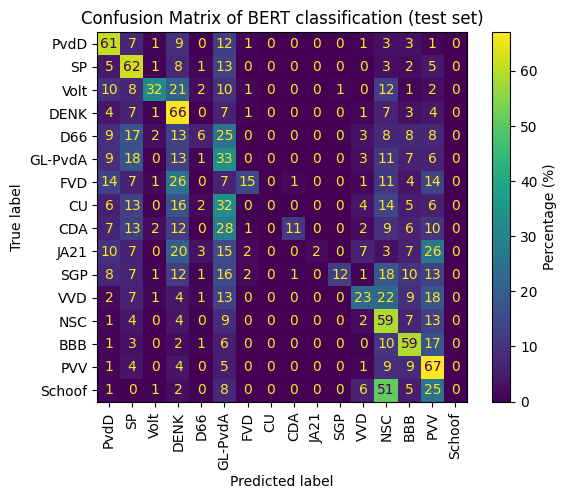

In [27]:
plot_confusion_matrix(all_labels, all_predictions)

This confusion matrix is sorted by our own left-right axis from the first latent factor.

As is visible, if a party is misclassified, it is often classified as a party with a similar ideology.

For example, Volt (Left) or D66 (RE) are often misclassified, but then they are mostly classified as other left-wing parties.

Similarly, SGP (ECR) and VVD (RE) are also often misclassified, but then they are mostly classified as other right-wing parties.

The effect of data skew is clearly visible for JA21 (ECR) and FVD (NI), as those parties are often classified as a plethora of other parties, both right-winged and left-winged.

Schoof (which cannot be guessed by the model) is most often classified as NSC. This is in line with the landscape.